# Preprocessing

### Loading

In [1]:
pip install cliffs-delta

Note: you may need to restart the kernel to use updated packages.


In [1]:
import openslide
from PIL import Image
import os
import numpy as np
import torch
import torch.nn as nn
import tifffile
import pandas as pd
from skimage.transform import downscale_local_mean
from skimage import filters, color
from math import ceil
from tqdm import tqdm
from torchvision.transforms import Normalize, Compose
from einops import rearrange
import random
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import timm
import glob
from timm import create_model
from huggingface_hub import login
import rsatoolbox
from rsatoolbox.data import Dataset
from rsatoolbox.rdm import calc_rdm
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, spearmanr, t
from scipy.cluster.hierarchy import linkage, dendrogram
from timm.layers import SwiGLUPacked
from scipy.spatial.distance import pdist, squareform
from cliffs_delta import cliffs_delta
import itertools
from itertools import combinations
import matplotlib.image as mpimg
from conch.open_clip_custom import create_model_from_pretrained
from transformers import CLIPModel, CLIPProcessor
from sklearn.preprocessing import normalize

/homes2/vmishra/miniconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### Splitting Into 5 Batches of 50 slides/50 patches each for validation

In [13]:
subtypes = ["brca", "coad", "luad", "lusc"]
models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]

base_path = "/lotterlab/users/vmishra/"
output_dir = "/lotterlab/users/vmishra/batched_embeddings"
os.makedirs(output_dir, exist_ok=True)

slides_per_batch = 50
patches_per_slide = 50

for subtype in subtypes:
    for model in models:
        file_path = os.path.join(base_path, f"{subtype}_embeddings_{model}.npy")
        print(f"Processing {file_path}...")

        embeddings = np.load(file_path)
        num_total = 250 * 250
        embedding_dim = embeddings.shape[1]
        assert embeddings.shape[0] == num_total, f"Unexpected shape for {file_path}"

        embeddings = embeddings.reshape(250, 250, embedding_dim)

        for batch_idx in range(5):
            start_slide = batch_idx * slides_per_batch
            end_slide = (batch_idx + 1) * slides_per_batch

            batch = embeddings[start_slide:end_slide, :patches_per_slide, :]
            batch = batch.reshape(-1, embedding_dim)

            batch_filename = f"{subtype}_{model}_batch{batch_idx+1}.npy"
            batch_path = os.path.join(output_dir, batch_filename)
            np.save(batch_path, batch)
            print(f"Saved batch {batch_idx+1} to {batch_path}")

Processing /lotterlab/users/vmishra/brca_embeddings_conch.npy...
Saved batch 1 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch1.npy
Saved batch 2 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch2.npy
Saved batch 3 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch3.npy
Saved batch 4 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch4.npy
Saved batch 5 to /lotterlab/users/vmishra/batched_embeddings/brca_conch_batch5.npy
Processing /lotterlab/users/vmishra/brca_embeddings_plip.npy...
Saved batch 1 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch1.npy
Saved batch 2 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch2.npy
Saved batch 3 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch3.npy
Saved batch 4 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch4.npy
Saved batch 5 to /lotterlab/users/vmishra/batched_embeddings/brca_plip_batch5.npy
Processing /lotterlab/users/vmishra/brca_embed

In [14]:
input_dir = "/lotterlab/users/vmishra/batched_embeddings"
rdm_output_dir = "/lotterlab/users/vmishra/rdms"
os.makedirs(rdm_output_dir, exist_ok=True)

subtypes = ["brca", "coad", "luad", "lusc"]
models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]

num_slides = 50
num_patches = 50

for model in models:
    for batch_idx in range(1, 6):
        print(f"Processing RDM for model: {model}, batch: {batch_idx}")

        embeddings_list = []
        labels = []

        for subtype in subtypes:
            file_path = os.path.join(input_dir, f"{subtype}_{model}_batch{batch_idx}.npy")
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}, skipping.")
                continue

            emb = np.load(file_path)
            embeddings_list.append(emb)
            labels.extend([subtype.upper()] * len(emb))

        if len(embeddings_list) < 4:
            print(f"Missing data for model {model}, batch {batch_idx}. Skipping.")
            continue

        embeddings = np.concatenate(embeddings_list, axis=0)

        dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
        rdm = calc_rdm(dataset, method='euclidean')
        rdm_matrix = rdm.get_matrices()[0]

        save_path = os.path.join(rdm_output_dir, f"rdm_matrix_{model}_batch{batch_idx}.npy")
        np.save(save_path, rdm_matrix)
        print(f"Saved RDM to {save_path}")

Processing RDM for model: conch, batch: 1
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch1.npy
Processing RDM for model: conch, batch: 2
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch2.npy
Processing RDM for model: conch, batch: 3
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch3.npy
Processing RDM for model: conch, batch: 4
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch4.npy
Processing RDM for model: conch, batch: 5
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_conch_batch5.npy
Processing RDM for model: plip, batch: 1
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch1.npy
Processing RDM for model: plip, batch: 2
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch2.npy
Processing RDM for model: plip, batch: 3
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_batch3.npy
Processing RDM for model: plip, batch: 4
Saved RDM to /lotterlab/users/vmishra/rdms/rdm_matrix_plip_ba

# Section 4.1

### Figure 1

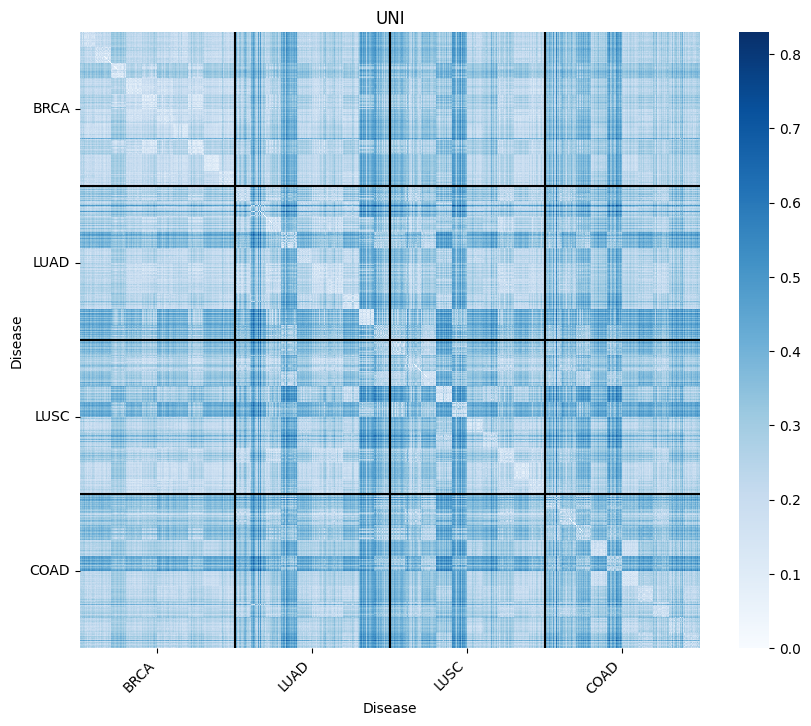

In [48]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_uni.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_uni.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_uni.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_uni.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_uni = calc_rdm(dataset, method='euclidean')
rdm_matrix_uni = rdm_uni.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_uni.npy", rdm_matrix_uni)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_uni, cmap='Blues', annot=False, cbar=True)
plt.title('UNI')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_uni.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_virchow.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_virchow.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_virchow.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_virchow.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_virchow = calc_rdm(dataset, method='euclidean')
rdm_matrix_virchow = rdm_virchow.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_virchow.npy", rdm_matrix_virchow)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_virchow, cmap='Blues', annot=False, cbar=True)
plt.title('Virchow')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_virchow.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_conch.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_conch.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_conch.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_conch.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_conch = calc_rdm(dataset, method='euclidean')
rdm_matrix_conch = rdm_conch.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_conch.npy", rdm_matrix_conch)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_conch, cmap='Blues', annot=False, cbar=True)
plt.title('CONCH')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_conch.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_prov.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_prov.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_prov.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_prov.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_prov = calc_rdm(dataset, method='euclidean')
rdm_matrix_prov = rdm_prov.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_prov.npy", rdm_matrix_prov)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_prov, cmap='Blues', annot=False, cbar=True)
plt.title('Prov-GigaPath')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_prov.png", dpi=300, bbox_inches='tight')
plt.show()

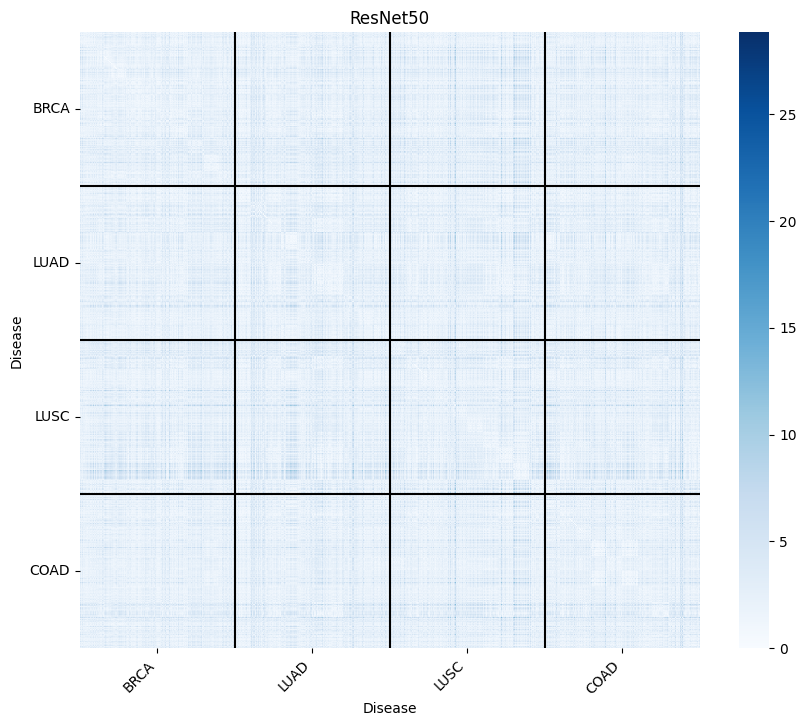

In [49]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_resnet.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_resnet.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_resnet.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_resnet.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_resnet = calc_rdm(dataset, method='euclidean')
rdm_matrix_resnet = rdm_resnet.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_resnet.npy", rdm_matrix_resnet)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_resnet, cmap='Blues', annot=False, cbar=True)
plt.title('ResNet50')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_resnet.png", dpi=300, bbox_inches='tight')
plt.show()

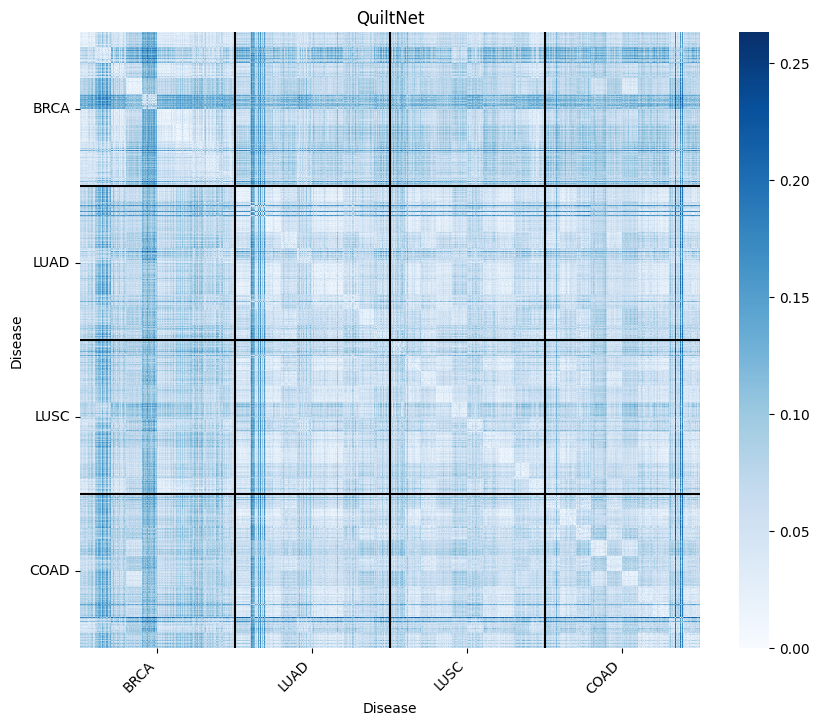

In [50]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_quiltnet.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_quiltnet.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_quiltnet.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_quiltnet.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_quiltnet = calc_rdm(dataset, method='euclidean')
rdm_matrix_quiltnet = rdm_quiltnet.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_quiltnet.npy", rdm_matrix_quiltnet)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_quiltnet, cmap='Blues', annot=False, cbar=True)
plt.title('QuiltNet')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_quiltnet.png", dpi=300, bbox_inches='tight')
plt.show()

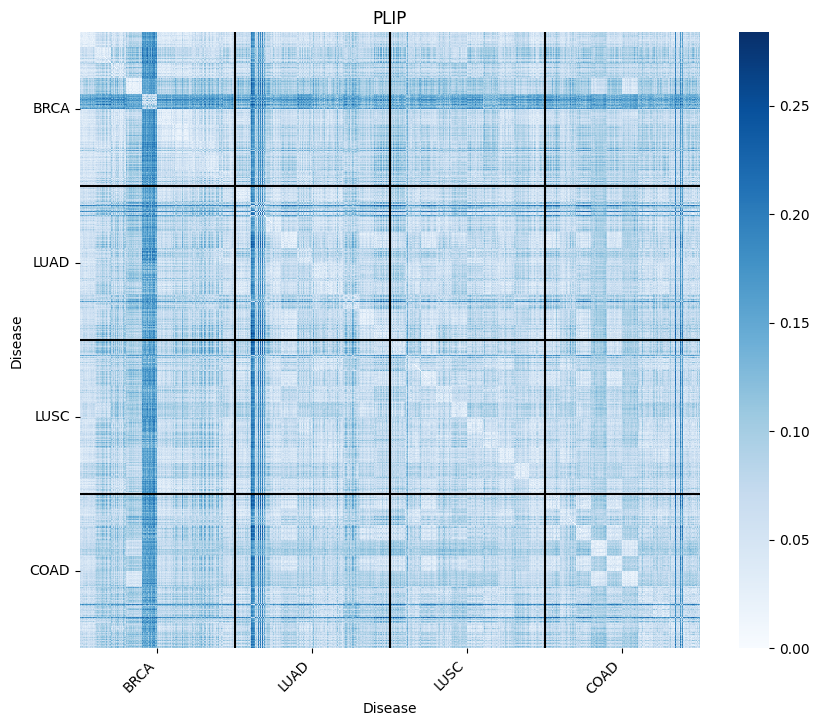

In [51]:
# Load embeddings
brca_embeddings = np.load("/lotterlab/users/vmishra/brca_embeddings_plip.npy")
luad_embeddings = np.load("/lotterlab/users/vmishra/luad_embeddings_plip.npy")
lusc_embeddings = np.load("/lotterlab/users/vmishra/lusc_embeddings_plip.npy")
coad_embeddings = np.load("/lotterlab/users/vmishra/coad_embeddings_plip.npy")

# Get counts
num_brca = len(brca_embeddings)
num_luad = len(luad_embeddings)
num_lusc = len(lusc_embeddings)
num_coad = len(coad_embeddings)

# Generate labels
brca_labels = [f"BRCA_{i+1}" for i in range(num_brca)]
luad_labels = [f"LUAD_{i+1}" for i in range(num_luad)]
lusc_labels = [f"LUSC_{i+1}" for i in range(num_lusc)]
coad_labels = [f"COAD_{i+1}" for i in range(num_coad)]

# Combine embeddings and labels
embeddings = np.concatenate([brca_embeddings, luad_embeddings, lusc_embeddings, coad_embeddings], axis=0)
labels = brca_labels + luad_labels + lusc_labels + coad_labels

num_slides = 50
num_patches_per_slide = 50

brca_sample = brca_embeddings[:num_slides * num_patches_per_slide]
luad_sample = luad_embeddings[:num_slides * num_patches_per_slide]
lusc_sample = lusc_embeddings[:num_slides * num_patches_per_slide]
coad_sample = coad_embeddings[:num_slides * num_patches_per_slide]

# Combine embeddings and labels
embeddings = np.concatenate([brca_sample, luad_sample, lusc_sample, coad_sample], axis=0)
labels = (["BRCA"] * len(brca_sample) +
          ["LUAD"] * len(luad_sample) +
          ["LUSC"] * len(lusc_sample) +
          ["COAD"] * len(coad_sample))

# Create dataset and compute RDM
dataset = Dataset(measurements=embeddings, obs_descriptors={'disease': labels})
rdm_plip = calc_rdm(dataset, method='euclidean')
rdm_matrix_plip = rdm_plip.get_matrices()[0]

# Save RDM
np.save("/lotterlab/users/vmishra/rdm_matrix_plip.npy", rdm_matrix_plip)

# Define disease label positions
divider_positions = [len(brca_sample), len(brca_sample) + len(luad_sample), len(brca_sample) + len(luad_sample) + len(lusc_sample)]

# Plot RDM
plt.figure(figsize=(10, 8))
ax = sns.heatmap(rdm_matrix_plip, cmap='Blues', annot=False, cbar=True)
plt.title('PLIP')
plt.xlabel('Disease')
plt.ylabel('Disease')
plt.xticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=45, ha='right')
plt.yticks([len(brca_sample) // 2, len(brca_sample) + len(luad_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) // 2, len(brca_sample) + len(luad_sample) + len(lusc_sample) + len(coad_sample) // 2],
           ["BRCA", "LUAD", "LUSC", "COAD"], rotation=0)

# Add divider lines between disease types
for pos in divider_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

plt.savefig("rdm_matrix_plip.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x1500 with 0 Axes>

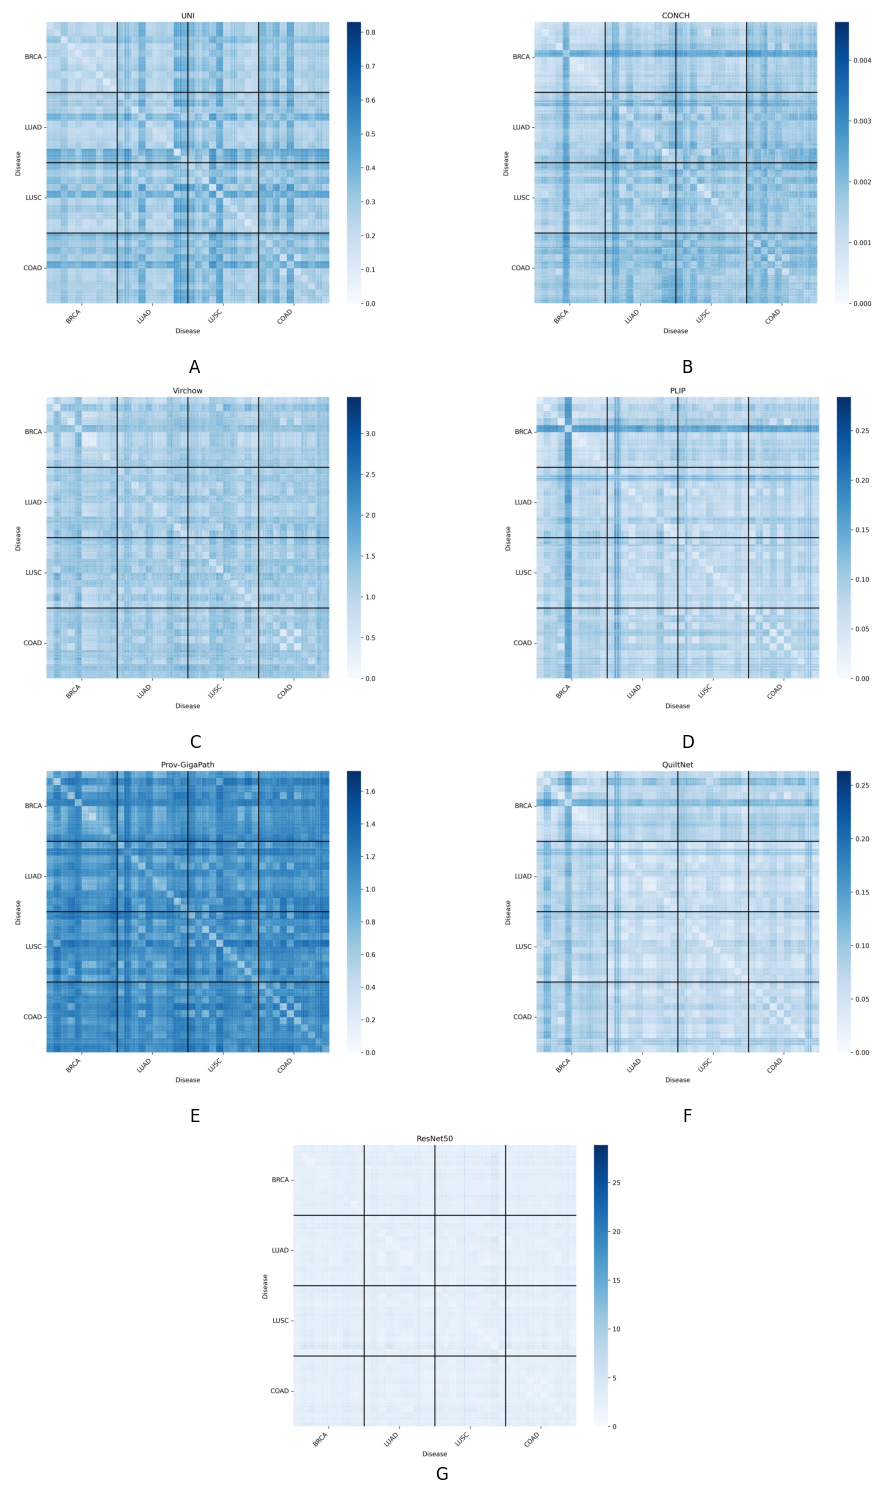

In [59]:
# Load the images
image_files = ['rdm_matrix_uni.png', 'rdm_matrix_conch.png', 'rdm_matrix_virchow.png', 
               'rdm_matrix_plip.png', 'rdm_matrix_prov.png', 'rdm_matrix_quiltnet.png', 
               'rdm_matrix_resnet.png']
images = [mpimg.imread(file) for file in image_files]

fig, axes = plt.subplots(4, 2, figsize=(10, 15))
axes_flat = axes.flatten()
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

for idx in range(6):
    axes_flat[idx].imshow(images[idx])
    axes_flat[idx].axis('off')
    axes_flat[idx].text(0.5, -0.1, labels[idx], size=12, ha="center", transform=axes_flat[idx].transAxes)

axes[3, 0].axis('off')
axes[3, 1].axis('off')

from matplotlib.gridspec import GridSpec

plt.clf()
fig = plt.figure(figsize=(10, 15))
gs = GridSpec(4, 2, figure=fig)

for idx in range(6):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    ax.imshow(images[idx])
    ax.axis('off')
    ax.text(0.5, -0.1, labels[idx], size=12, ha="center", transform=ax.transAxes)

ax_center = fig.add_subplot(gs[3, :])
ax_center.imshow(images[6])
ax_center.axis('off')
ax_center.text(0.5, -0.05, labels[6], size=12, ha="center", transform=ax_center.transAxes)

plt.tight_layout()
plt.savefig('combined_centered.png', dpi=400)
plt.show()

In [52]:
from PIL import Image

img = Image.open("rdm_matrix_uni.png")
img.save("rdm_matrix_uni.pdf", "PDF", resolution=300.0)

In [53]:
img = Image.open("rdm_matrix_prov.png")
img.save("rdm_matrix_prov.pdf", "PDF", resolution=300.0)

In [54]:
img = Image.open("rdm_matrix_virchow.png")
img.save("rdm_matrix_virchow.pdf", "PDF", resolution=300.0)

In [55]:
img = Image.open("rdm_matrix_plip.png")
img.save("rdm_matrix_plip.pdf", "PDF", resolution=300.0)

In [56]:
img = Image.open("rdm_matrix_quiltnet.png")
img.save("rdm_matrix_quiltnet.pdf", "PDF", resolution=300.0)

In [57]:
img = Image.open("rdm_matrix_conch.png")
img.save("rdm_matrix_conch.pdf", "PDF", resolution=300.0)

In [58]:
img = Image.open("rdm_matrix_resnet.png")
img.save("rdm_matrix_resnet.pdf", "PDF", resolution=300.0)

### Figures 2

In [ ]:
from scipy.stats import spearmanr, t

models = ["conch", "plip", "prov", "quiltnet", "resnet", "uni", "virchow"]
n_models = len(models)
rdm_dir = "/lotterlab/users/vmishra/rdms"

cosine_mean = np.zeros((n_models, n_models))
cosine_ci_lower = np.zeros((n_models, n_models))
cosine_ci_upper = np.zeros((n_models, n_models))

pearson_mean = np.zeros((n_models, n_models))
pearson_ci_lower = np.zeros((n_models, n_models))
pearson_ci_upper = np.zeros((n_models, n_models))

spearman_mean = np.zeros((n_models, n_models))
spearman_ci_lower = np.zeros((n_models, n_models))
spearman_ci_upper = np.zeros((n_models, n_models))

def get_confidence_interval(values, confidence=0.95):
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    n = len(values)
    h = t.ppf((1 + confidence) / 2., n - 1) * std / np.sqrt(n)
    return mean, mean - h, mean + h

for i, model_i in enumerate(models):
    for j, model_j in enumerate(models):
        cosine_vals = []
        pearson_vals = []
        spearman_vals = []

        for batch in range(1, 6):
            path_i = os.path.join(rdm_dir, f"rdm_matrix_{model_i}_batch{batch}.npy")
            path_j = os.path.join(rdm_dir, f"rdm_matrix_{model_j}_batch{batch}.npy")
            rdm_i = np.load(path_i)
            rdm_j = np.load(path_j)

            tri_i = rdm_i[np.triu_indices_from(rdm_i, k=1)]
            tri_j = rdm_j[np.triu_indices_from(rdm_j, k=1)]

            cos_sim = 1 - cosine(tri_i, tri_j)
            pearson_corr, _ = pearsonr(tri_i, tri_j)
            spearman_corr, _ = spearmanr(tri_i, tri_j)

            cosine_vals.append(cos_sim)
            pearson_vals.append(pearson_corr)
            spearman_vals.append(spearman_corr)

        # Cosine
        mean_cos, ci_cos_low, ci_cos_high = get_confidence_interval(cosine_vals)
        cosine_mean[i, j] = mean_cos
        cosine_ci_lower[i, j] = ci_cos_low
        cosine_ci_upper[i, j] = ci_cos_high

        # Pearson
        mean_pear, ci_pear_low, ci_pear_high = get_confidence_interval(pearson_vals)
        pearson_mean[i, j] = mean_pear
        pearson_ci_lower[i, j] = ci_pear_low
        pearson_ci_upper[i, j] = ci_pear_high

        # Spearman
        mean_spear, ci_spear_low, ci_spear_high = get_confidence_interval(spearman_vals)
        spearman_mean[i, j] = mean_spear
        spearman_ci_lower[i, j] = ci_spear_low
        spearman_ci_upper[i, j] = ci_spear_high

# Desired model order and display names
desired_order = ['uni', 'virchow', 'prov', 'conch', 'plip', 'quiltnet', 'resnet']
display_names = ['UNI', 'Virchow', 'Prov-GigaPath', 'CONCH', 'PLIP', 'QuiltNet', 'ResNet-50']
reorder_idx = [models.index(m) for m in desired_order]

# Reorder all matrices
cosine_mean_r = cosine_mean[reorder_idx, :][:, reorder_idx]
cosine_ci_lower_r = cosine_ci_lower[reorder_idx, :][:, reorder_idx]
cosine_ci_upper_r = cosine_ci_upper[reorder_idx, :][:, reorder_idx]

pearson_mean_r = pearson_mean[reorder_idx, :][:, reorder_idx]
pearson_ci_lower_r = pearson_ci_lower[reorder_idx, :][:, reorder_idx]
pearson_ci_upper_r = pearson_ci_upper[reorder_idx, :][:, reorder_idx]

spearman_mean_r = spearman_mean[reorder_idx, :][:, reorder_idx]
spearman_ci_lower_r = spearman_ci_lower[reorder_idx, :][:, reorder_idx]
spearman_ci_upper_r = spearman_ci_upper[reorder_idx, :][:, reorder_idx]

def format_annot(mean_mat, lower_mat, upper_mat):
    n = mean_mat.shape[0]
    annot = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            m = mean_mat[i, j]
            l = lower_mat[i, j]
            u = upper_mat[i, j]
            annot[i, j] = f"{m:.3f}\n[{l:.3f}–{u:.3f}]"
    return annot

cosine_annot = format_annot(cosine_mean_r, cosine_ci_lower_r, cosine_ci_upper_r)
pearson_annot = format_annot(pearson_mean_r, pearson_ci_lower_r, pearson_ci_upper_r)
spearman_annot = format_annot(spearman_mean_r, spearman_ci_lower_r, spearman_ci_upper_r)

# === PLOT COSINE SIMILARITY ===
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_mean_r, annot=cosine_annot, fmt="", xticklabels=display_names, yticklabels=display_names,
            cmap="Reds", vmin=0.85, vmax=1, cbar_kws={"label": "Cosine Similarity"})
plt.title("Cosine Similarity Between Model RDMs\nMean ± 95% CI (Across 5 Batches)")
plt.tight_layout()
plt.savefig("cosineHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

# === PLOT PEARSON CORRELATION ===
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_mean_r, annot=pearson_annot, fmt="", xticklabels=display_names, yticklabels=display_names,
            cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "Pearson Correlation"})
plt.title("Pearson Correlation Between Model RDMs\nMean ± 95% CI (Across 5 Batches)")
plt.tight_layout()
plt.savefig("pearsonHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

# === PLOT SPEARMAN CORRELATION ===
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_mean_r, annot=spearman_annot, fmt="", xticklabels=display_names, yticklabels=display_names,
            cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "Spearman Correlation"})
plt.title("Spearman Correlation Between Model RDMs\nMean ± 95% CI (Across 5 Batches)")
plt.tight_layout()
plt.savefig("spearmanHeatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Table 2

In [34]:
n_models = len(display_names)

average_cosine_sim = (np.sum(cosine_mean_r, axis=1) - np.diag(cosine_mean_r)) / (n_models - 1)
average_pearson_corr = (np.sum(pearson_mean_r, axis=1) - np.diag(pearson_mean_r)) / (n_models - 1)
average_spearman_corr = (np.sum(spearman_mean_r, axis=1) - np.diag(spearman_mean_r)) / (n_models - 1)


df_similarity = pd.DataFrame({
    "Model": display_names,
    "Average Cosine Similarity": average_cosine_sim,
    "Average Pearson Correlation": average_pearson_corr,
    "Average Spearman Correlation": average_spearman_corr
})

df_similarity

,Model,Average Cosine Similarity,Average Pearson Correlation,Average Spearman Correlation
0,UNI,0.929971,0.275170,0.271772
1,Virchow,0.932258,0.328128,0.345689
2,Prov-GigaPath,0.952321,0.446068,0.436080
3,CONCH,0.936043,0.399313,0.386029
4,PLIP,0.936614,0.451499,0.439151
5,QuiltNet,0.933395,0.408355,0.398649
6,ResNet-50,0.884715,0.163772,0.167526


### Appendix 1

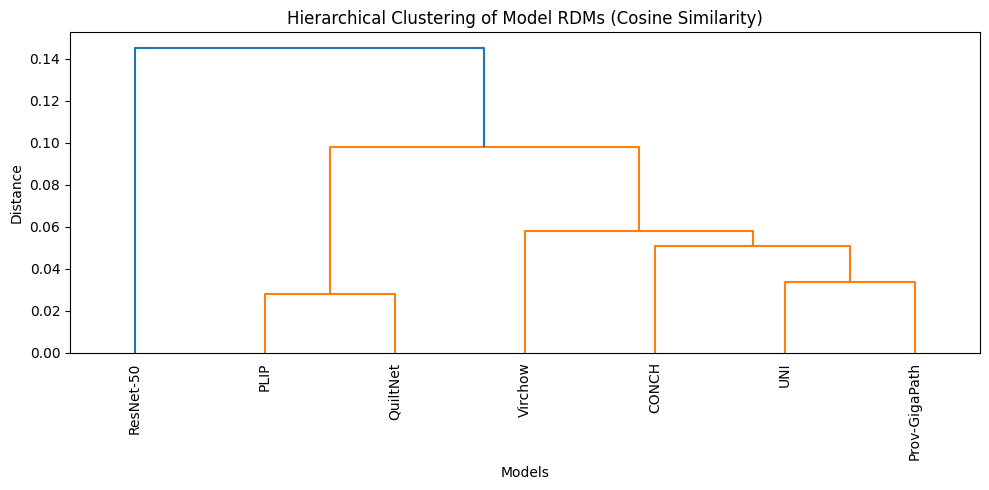

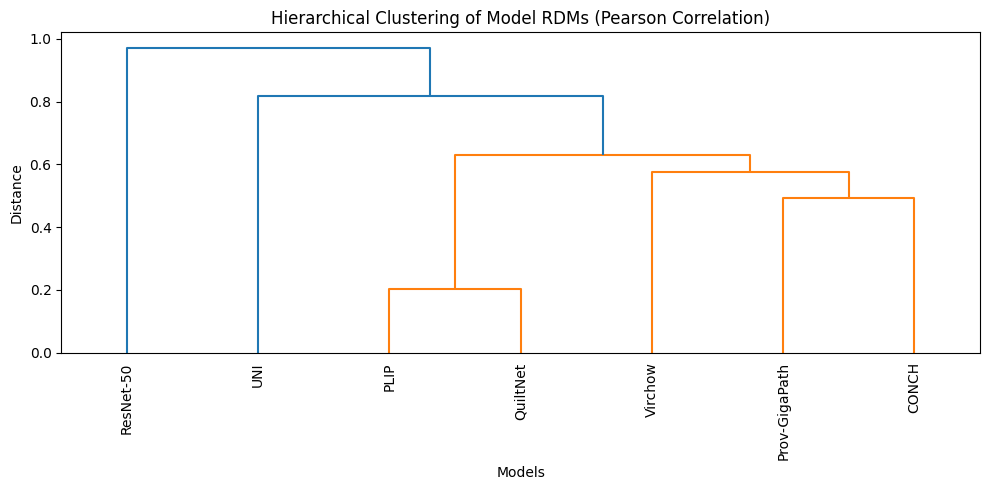

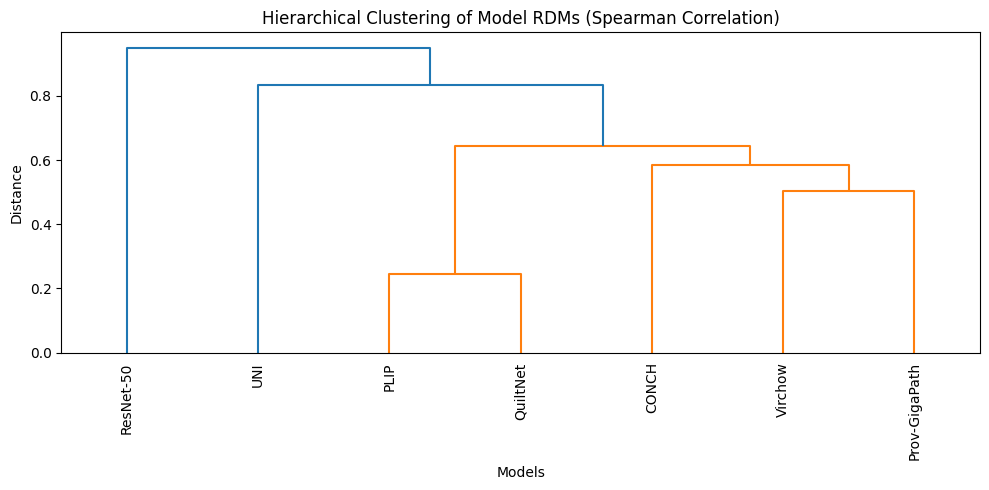

In [35]:
# Load RDMs
rdm_conch = np.load("/lotterlab/users/vmishra/rdm_matrix_conch.npy")
rdm_plip = np.load("/lotterlab/users/vmishra/rdm_matrix_plip.npy")
rdm_virchow = np.load("/lotterlab/users/vmishra/rdm_matrix_virchow.npy")
rdm_uni = np.load("/lotterlab/users/vmishra/rdm_matrix_uni.npy")
rdm_quiltnet = np.load("/lotterlab/users/vmishra/rdm_matrix_quiltnet.npy")
rdm_prov = np.load("/lotterlab/users/vmishra/rdm_matrix_prov.npy")
rdm_resnet = np.load("/lotterlab/users/vmishra/rdm_matrix_resnet.npy")

# Create dictionary of RDMs (flattened to vectors)
rdm_dict = {
    "UNI": rdm_uni.flatten(),
    "Virchow": rdm_virchow.flatten(),
    "Prov-GigaPath": rdm_prov.flatten(),    
    "CONCH": rdm_conch.flatten(),
    "PLIP": rdm_plip.flatten(),
    "QuiltNet": rdm_quiltnet.flatten(),
    "ResNet-50": rdm_resnet.flatten()
}

# Initialize similarity matrices
models = list(rdm_dict.keys())
n_models = len(models)
cosine_similarities = np.zeros((n_models, n_models))
correlation_similarities = np.zeros((n_models, n_models))
spearman_similarities = np.zeros((n_models, n_models))

# Compute pairwise similarities
for i, model_i in enumerate(models):
    for j, model_j in enumerate(models):
        cosine_similarities[i, j] = 1 - cosine(rdm_dict[model_i], rdm_dict[model_j])
        correlation_similarities[i, j], _ = pearsonr(rdm_dict[model_i], rdm_dict[model_j])
        spearman_similarities[i, j], _ = spearmanr(rdm_dict[model_i], rdm_dict[model_j])

# Convert similarity to distance
cosine_distances = 1 - cosine_similarities
correlation_distances = 1 - correlation_similarities
spearman_distances = 1 - spearman_similarities

# Convert to condensed form
cosine_condensed = squareform(cosine_distances, checks=False)
correlation_condensed = squareform(correlation_distances, checks=False)
spearman_condensed = squareform(spearman_distances, checks=False)

# Hierarchical Clustering (Ward's method)
linkage_cosine = linkage(cosine_condensed, method="ward")
linkage_correlation = linkage(correlation_condensed, method="ward")
linkage_spearman = linkage(spearman_condensed, method="ward")

# Plot Dendrogram (Cosine Similarity)
plt.figure(figsize=(10, 5))
dendrogram(linkage_cosine, labels=models, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Model RDMs (Cosine Similarity)")
plt.xlabel("Models")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig('ClusteringCosine.pdf')
plt.show()

# Plot Dendrogram (Pearson Correlation)
plt.figure(figsize=(10, 5))
dendrogram(linkage_correlation, labels=models, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Model RDMs (Pearson Correlation)")
plt.xlabel("Models")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig('ClusteringPearson.pdf')
plt.show()

# Plot Dendrogram (Spearman Correlation)
plt.figure(figsize=(10, 5))
dendrogram(linkage_spearman, labels=models, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Model RDMs (Spearman Correlation)")
plt.xlabel("Models")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig('ClusteringSpearman.pdf')
plt.show()

# Section 4.2

### Table 3 (Slide Specificity)

In [3]:
from bisect import bisect_right, bisect_left
from scipy.spatial.distance import pdist
from scipy.stats import t

models = ['conch', 'plip', 'virchow', 'uni', 'quiltnet', 'prov', 'resnet']
display_names = ['CONCH', 'PLIP', 'Virchow', 'UNI', 'QuiltNet', 'Prov-GigaPath', 'ResNet-50']
subtypes = ['brca', 'luad', 'lusc', 'coad']
num_slides = 50
patches_per_slide = 50
n_batches = 5
rdm_root = "/lotterlab/users/vmishra/batched_embeddings"

def calculate_distances(embeddings, num_slides=50, patches_per_slide=50):
    intra_distances = []
    inter_distances = []

    for slide_idx in range(num_slides):
        slide_indices = np.arange(slide_idx * patches_per_slide, (slide_idx + 1) * patches_per_slide)
        other_indices = np.setdiff1d(np.arange(embeddings.shape[0]), slide_indices)

        slide_distances = pdist(embeddings[slide_indices], metric='euclidean')
        intra_distances.extend(slide_distances)

        for other_idx in other_indices:
            inter_distances.extend(np.linalg.norm(embeddings[slide_indices] - embeddings[other_idx], axis=1))

    return np.array(intra_distances), np.array(inter_distances)

def cliffs_delta(a, b):
    m, n = len(a), len(b)
    greater = np.sum(a[:, None] > b)
    less = np.sum(a[:, None] < b)
    delta = (greater - less) / (m * n)
    return delta

def efficient_cliffs_delta(a, b):
    a = np.sort(a)
    b = np.sort(b)
    m, n = len(a), len(b)
    more = sum(bisect_right(b, x) for x in a)
    less = sum(n - bisect_left(b, x) for x in a)
    delta = (more - less) / (m * n)
    return delta

def dprime(a, b):
    mu_1, sigma_1 = np.mean(a), np.std(a)
    mu_2, sigma_2 = np.mean(b), np.std(b)
    pooled_std = np.sqrt((sigma_1**2 + sigma_2**2) / 2)
    return (mu_1 - mu_2) / pooled_std

def compute_ci(values, ci=95):
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    n = len(values)
    h = t.ppf((1 + ci / 100) / 2, n - 1) * std / np.sqrt(n)
    return mean, mean - h, mean + h

results = []

for model in tqdm(models, desc="Processing models"):
    delta_vals = []
    dprime_vals = []

    for batch in range(1, n_batches + 1):
        embeddings_list = []
        for subtype in subtypes:
            file_path = os.path.join(rdm_root, f"{subtype}_{model}_batch{batch}.npy")
            emb = np.load(file_path)
            embeddings_list.append(emb)

        all_embeddings = np.vstack(embeddings_list)
        intra, inter = calculate_distances(all_embeddings, num_slides=num_slides * 4, patches_per_slide=patches_per_slide)

        delta_vals.append(efficient_cliffs_delta(intra, inter))
        dprime_vals.append(dprime(intra, inter))

    delta_mean, delta_low, delta_high = compute_ci(delta_vals)
    dprime_mean, dprime_low, dprime_high = compute_ci(dprime_vals)

    results.append({
        "model": model,
        "display_name": display_names[models.index(model)],
        "cliffs_delta": delta_mean,
        "cliffs_ci_low": delta_low,
        "cliffs_ci_high": delta_high,
        "dprime": dprime_mean,
        "dprime_ci_low": dprime_low,
        "dprime_ci_high": dprime_high
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cliffs_delta", ascending=False).reset_index(drop=True)
results_df.to_csv("slide_specificity_cliffs_dprime_mean_ci.csv", index=False)
print(results_df)

Processing models: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [53:28<00:00, 458.39s/it]

      model   display_name  cliffs_delta  cliffs_ci_low  cliffs_ci_high  \
0    resnet      ResNet-50     -0.431175      -0.443493       -0.418856   
1     conch          CONCH     -0.597020      -0.616293       -0.577747   
2   virchow        Virchow     -0.612947      -0.628454       -0.597440   
3      plip           PLIP     -0.708291      -0.723613       -0.692970   
4  quiltnet       QuiltNet     -0.731389      -0.745587       -0.717190   
5      prov  Prov-GigaPath     -0.751410      -0.761554       -0.741265   
6       uni            UNI     -0.753429      -0.772211       -0.734646   

     dprime  dprime_ci_low  dprime_ci_high  
0 -0.755516      -0.783085       -0.727946  
1 -1.187423      -1.239152       -1.135694  
2 -1.210410      -1.253733       -1.167087  
3 -1.426608      -1.494012       -1.359203  
4 -1.520607      -1.581617       -1.459597  
5 -1.632299      -1.664092       -1.600507  
6 -1.619583      -1.692511       -1.546654  


In [4]:
models = ['conch', 'plip', 'virchow', 'uni', 'quiltnet', 'prov', 'resnet']
display_names = ['CONCH', 'PLIP', 'Virchow', 'UNI', 'QuiltNet', 'Prov-GigaPath', 'ResNet-50']
subtypes = ['brca', 'luad', 'lusc', 'coad']
num_slides = 50
patches_per_slide = 50
n_batches = 5
embedding_dir = "/lotterlab/users/vmishra/batched_embeddings"

def efficient_cliffs_delta(a, b):
    a = np.sort(a)
    b = np.sort(b)
    m, n = len(a), len(b)
    more = sum(bisect_right(b, x) for x in a)
    less = sum(n - bisect_left(b, x) for x in a)
    delta = (more - less) / (m * n)
    return delta

def dprime(a, b):
    mu_1, sigma_1 = np.mean(a), np.std(a)
    mu_2, sigma_2 = np.mean(b), np.std(b)
    pooled_std = np.sqrt((sigma_1**2 + sigma_2**2) / 2)
    return (mu_1 - mu_2) / pooled_std

def compute_ci(values, ci=95):
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    n = len(values)
    h = t.ppf((1 + ci / 100) / 2, n - 1) * std / np.sqrt(n)
    return mean, mean - h, mean + h

results = []

for model in tqdm(models, desc="Processing models"):
    delta_vals = []
    dprime_vals = []

    for batch in range(1, n_batches + 1):
        disease_embeddings = {}
        for subtype in subtypes:
            file_path = os.path.join(embedding_dir, f"{subtype}_{model}_batch{batch}.npy")
            disease_embeddings[subtype] = np.load(file_path)

        intra_distances = []
        for subtype in subtypes:
            emb = disease_embeddings[subtype]
            dists = pdist(emb, metric='euclidean')
            intra_distances.extend(dists)

        inter_distances = []
        for i in range(len(subtypes)):
            for j in range(i + 1, len(subtypes)):
                emb1 = disease_embeddings[subtypes[i]]
                emb2 = disease_embeddings[subtypes[j]]
                n = min(len(emb1), len(emb2), 2500)
                idx1 = np.random.choice(len(emb1), n, replace=False)
                idx2 = np.random.choice(len(emb2), n, replace=False)
                diffs = np.linalg.norm(emb1[idx1] - emb2[idx2], axis=1)
                inter_distances.extend(diffs)

        intra = np.array(intra_distances)
        inter = np.array(inter_distances)

        delta_vals.append(efficient_cliffs_delta(intra, inter))
        dprime_vals.append(dprime(intra, inter))

    delta_mean, delta_low, delta_high = compute_ci(delta_vals)
    dprime_mean, dprime_low, dprime_high = compute_ci(dprime_vals)

    results.append({
        "model": model,
        "display_name": display_names[models.index(model)],
        "cliffs_delta": delta_mean,
        "cliffs_ci_low": delta_low,
        "cliffs_ci_high": delta_high,
        "dprime": dprime_mean,
        "dprime_ci_low": dprime_low,
        "dprime_ci_high": dprime_high
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cliffs_delta", ascending=False).reset_index(drop=True)
results_df.to_csv("disease_specificity_cliffs_dprime_mean_ci.csv", index=False)
print(results_df)

Processing models: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [21:31<00:00, 184.55s/it]

      model   display_name  cliffs_delta  cliffs_ci_low  cliffs_ci_high  \
0    resnet      ResNet-50     -0.035139      -0.040750       -0.029529   
1   virchow        Virchow     -0.090259      -0.101912       -0.078606   
2      prov  Prov-GigaPath     -0.101338      -0.114253       -0.088423   
3     conch          CONCH     -0.101767      -0.112941       -0.090593   
4      plip           PLIP     -0.105650      -0.119473       -0.091827   
5       uni            UNI     -0.113772      -0.129964       -0.097580   
6  quiltnet       QuiltNet     -0.174320      -0.189683       -0.158956   

     dprime  dprime_ci_low  dprime_ci_high  
0 -0.056831      -0.067532       -0.046129  
1 -0.168455      -0.188303       -0.148607  
2 -0.200634      -0.221012       -0.180255  
3 -0.190464      -0.209580       -0.171348  
4 -0.180220      -0.199180       -0.161260  
5 -0.206171      -0.231302       -0.181040  
6 -0.301990      -0.326208       -0.277772  


# Section 4.3


Processing UNI...
Running SVD for UNI...

Processing Virchow...
Running SVD for Virchow...

Processing Prov-GigaPath...
Running SVD for Prov-GigaPath...

Processing CONCH...
Running SVD for CONCH...

Processing PLIP...
Running SVD for PLIP...

Processing QuiltNet...
Running SVD for QuiltNet...

Processing ResNet-50...
Running SVD for ResNet-50...


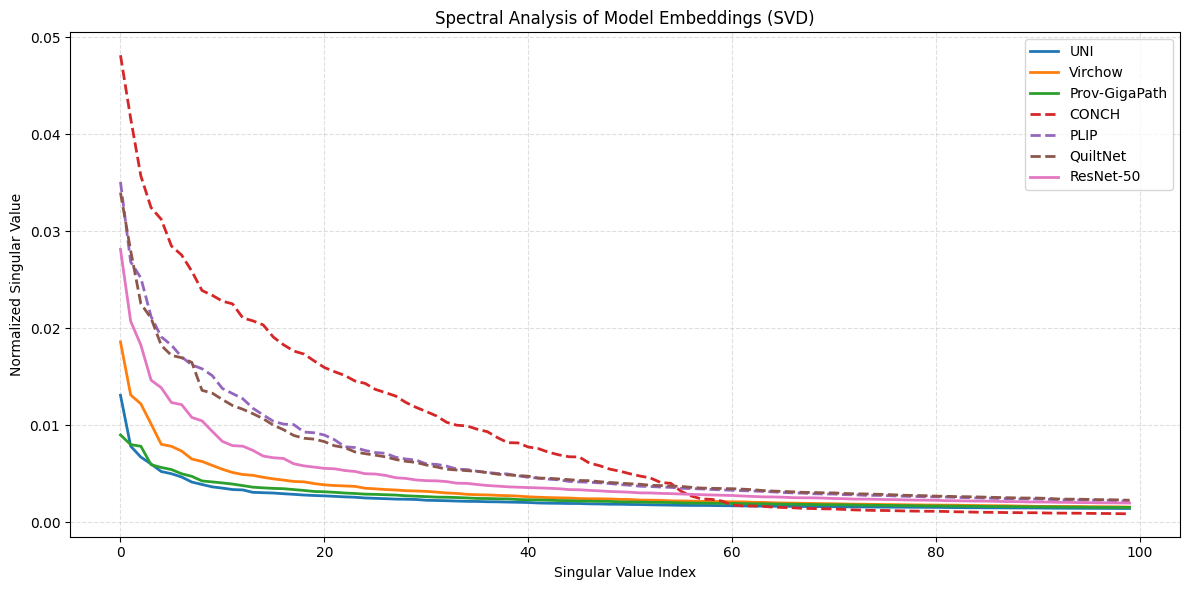

In [36]:
models = ["UNI", "Virchow", "Prov-GigaPath", "CONCH", "PLIP", "QuiltNet", "ResNet-50"]
model_file_keys = {
    "UNI": "uni",
    "Virchow": "virchow",
    "Prov-GigaPath": "prov",
    "CONCH": "conch",
    "PLIP": "plip",
    "QuiltNet": "quiltnet",
    "ResNet-50": "resnet"
}

vl_models = ["PLIP", "QuiltNet", "CONCH"]
subtypes = ["brca", "coad", "luad", "lusc"]

embedding_dir = "/lotterlab/users/vmishra"

spectra = {}

for model_name in models:
    model_key = model_file_keys[model_name]
    embeddings_list = []

    print(f"\nProcessing {model_name}...")
    for subtype in subtypes:
        file_path = os.path.join(embedding_dir, f"{subtype}_embeddings_{model_key}.npy")
        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        emb = np.load(file_path)
        embeddings_list.append(emb)

    if len(embeddings_list) < 4:
        print(f"Skipping {model_name} due to missing data.")
        continue

    embeddings = np.concatenate(embeddings_list, axis=0)

    # Normalize and center
    embeddings = normalize(embeddings, axis=1)
    embeddings -= embeddings.mean(axis=0)

    # SVD
    print(f"Running SVD for {model_name}...")
    U, S, Vt = np.linalg.svd(embeddings, full_matrices=False)
    normalized_spectrum = S / S.sum()
    spectra[model_name] = normalized_spectrum

plt.figure(figsize=(12, 6))

for model_name, spectrum in spectra.items():
    line_style = '--' if model_name in vl_models else '-'
    plt.plot(spectrum[:100], label=model_name, linewidth=2, linestyle=line_style)

plt.xlabel("Singular Value Index")
plt.ylabel("Normalized Singular Value")
plt.title("Spectral Analysis of Model Embeddings (SVD)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("spectral_analysis_svd.pdf", dpi=300)
plt.show()

# Model Number of Parameters

In [29]:
model, preprocess = create_model_from_pretrained(
    'conch_ViT-B-16',
    "hf_hub:MahmoodLab/conch",
    hf_auth_token="YOUR_HF_TOKEN"
)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_conch = total_params

/homes2/vmishra/miniconda3/lib/python3.12/site-packages/conch/open_clip_custom/factory.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoin

Total parameters: 395,232,769
Trainable parameters: 395,232,769


In [30]:
model = timm.create_model(
    "hf-hub:paige-ai/Virchow2",
    pretrained=True,
    mlp_layer=SwiGLUPacked,
    act_layer=torch.nn.SiLU
)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_virchow = total_params

Total parameters: 631,239,424
Trainable parameters: 631,239,424


In [31]:
timm_kwargs = {
    'img_size': 224,
    'patch_size': 14,
    'depth': 24,
    'num_heads': 24,
    'init_values': 1e-5,
    'embed_dim': 1536,
    'mlp_ratio': 2.66667 * 2,
    'num_classes': 0,
    'no_embed_class': True,
    'mlp_layer': timm.layers.SwiGLUPacked,
    'act_layer': torch.nn.SiLU,
    'reg_tokens': 8,
    'dynamic_img_size': True
}
model = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
model.eval()
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_uni = total_params

Total parameters: 681,394,176
Trainable parameters: 681,394,176


In [32]:
model = CLIPModel.from_pretrained("wisdomik/QuiltNet-B-32")

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_quiltnet = total_params

Total parameters: 151,277,313
Trainable parameters: 151,277,313


In [33]:
model = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_prov = total_params

Total parameters: 1,134,953,984
Trainable parameters: 1,134,953,984


In [34]:
model = CLIPModel.from_pretrained("vinid/plip")

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_plip = total_params

Total parameters: 151,277,313
Trainable parameters: 151,277,313


In [35]:
model = timm.create_model("resnet50", pretrained=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
total_params_resnet = total_params

Total parameters: 25,557,032
Trainable parameters: 25,557,032
